<a href="https://colab.research.google.com/github/patilhumesh88-spec/ML_python/blob/main/Chp_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mglearn
import mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 12.5 MB/s eta 0:00:00


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


X.shape:(26, 2)


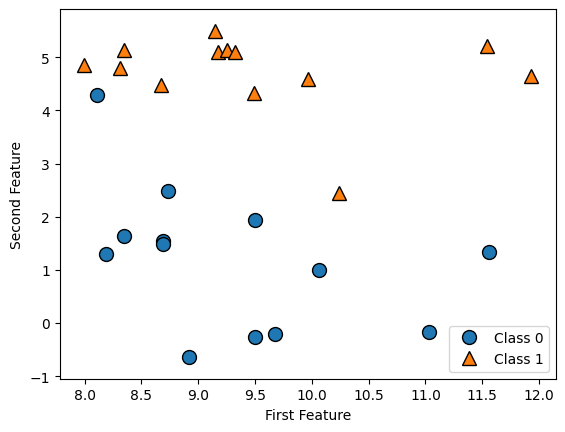

In [3]:
#generate dataset
X,y = mglearn.datasets.make_forge()
# plot dataset
mglearn.discrete_scatter(X[:,0],X[:,1],y)
plt.legend(["Class 0","Class 1"],loc=4)
plt.xlabel("First Feature")
plt.ylabel("Second Feature")
print("X.shape:{}".format(X.shape))

Text(0, 0.5, 'Target')

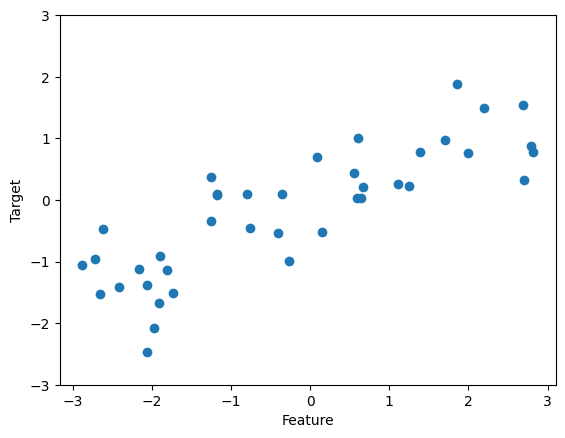

In [4]:
X,y = mglearn.datasets.make_wave(n_samples=40)
plt.plot(X,y,'o')
plt.ylim(-3,3)
plt.xlabel("Feature")
plt.ylabel("Target")

In [5]:
import sklearn
from sklearn.datasets import load_breast_cancer
cancer=load_breast_cancer()
print("cancer.keys():\n{}".format(cancer.keys()))

cancer.keys():
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [6]:
print("Shape of cancer data:{}".format(cancer.data.shape))

Shape of cancer data:(569, 30)


In [7]:
print("Sample counts per class :\n{}".format({n:v for n,v in zip(cancer.target_names,np.bincount(cancer.target))}))

Sample counts per class :
{np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


In [8]:
print("Feature names:\n{}".format(cancer.feature_names))

Feature names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [9]:
print(cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [10]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
print("Data shape:{}".format(housing.data.shape))

Data shape:(20640, 8)


In [11]:
X,y = mglearn.datasets.load_extended_boston()
print("X.shape:{}".format(X.shape))

X.shape:(506, 104)


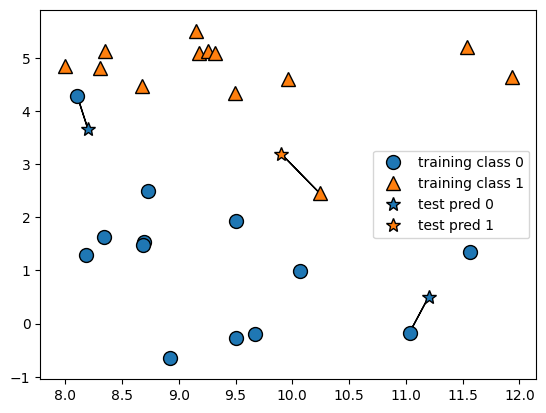

In [12]:
mglearn.plots.plot_knn_classification(n_neighbors=1)

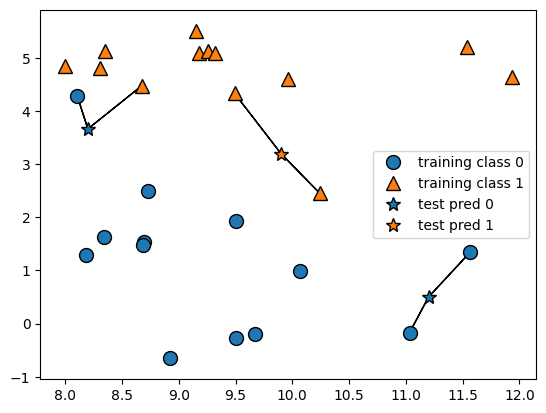

In [13]:
mglearn.plots.plot_knn_classification(n_neighbors=2)

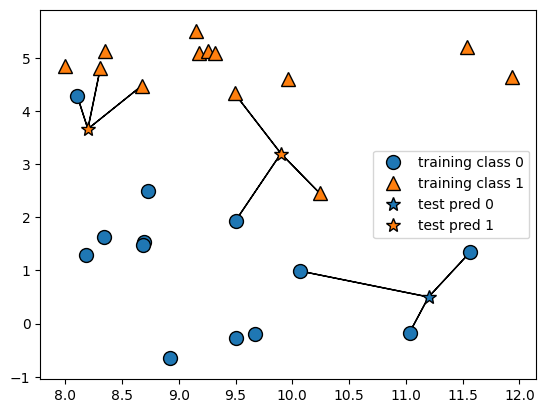

In [14]:
mglearn.plots.plot_knn_classification(n_neighbors=3)

In [15]:
from sklearn.model_selection import train_test_split
X,y = mglearn.datasets.make_forge()
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=0)


In [16]:
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3)

In [17]:
clf.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [18]:
print("Test set predictions:{}".format(clf.predict(X_test)))

Test set predictions:[1 0 1 0 1 0 0]


In [19]:
print("Test set accuracy:{}".format(clf.score(X_test,y_test)))

Test set accuracy:0.8571428571428571


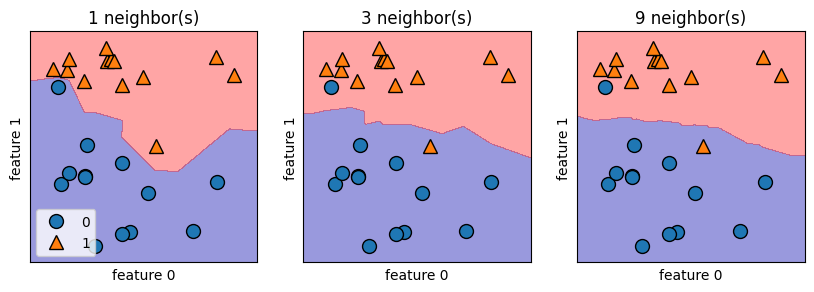

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for n_neighbors, ax in zip([1, 3, 9], axes):
# the fit method returns the object self, so we can instantiate
# and fit in one line
   clf = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X, y)
   mglearn.plots.plot_2d_separator(clf, X, fill=True, eps=0.5, ax=ax, alpha=.4)
   mglearn.discrete_scatter(X[:, 0], X[:, 1], y, ax=ax)
   ax.set_title("{} neighbor(s)".format(n_neighbors))
   ax.set_xlabel("feature 0")
   ax.set_ylabel("feature 1")
axes[0].legend(loc=3)

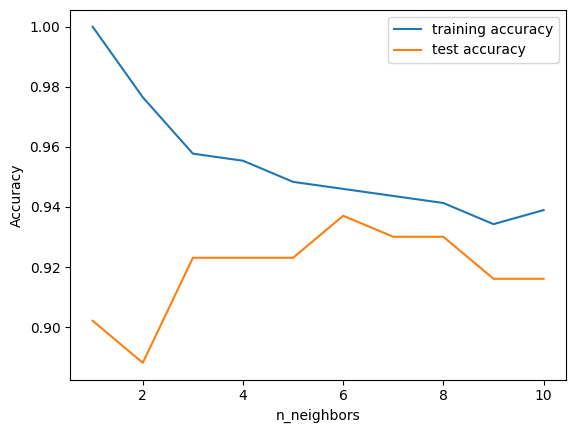

In [21]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
   cancer.data, cancer.target, stratify=cancer.target, random_state=66)
training_accuracy=[]
test_accuracy=[]
# try n_neighbors from 1 to 10
neighbors_settings=range(1,11)
for n_neighbors in neighbors_settings:
   # build the model
   clf=KNeighborsClassifier(n_neighbors=n_neighbors)
   clf.fit(X_train,y_train)
   #record training set accuracy
   training_accuracy.append(clf.score(X_train,y_train))
   #record generalization accuracy
   test_accuracy.append(clf.score(X_test,y_test))

plt.plot(neighbors_settings,training_accuracy,label="training accuracy")
plt.plot(neighbors_settings,test_accuracy,label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()


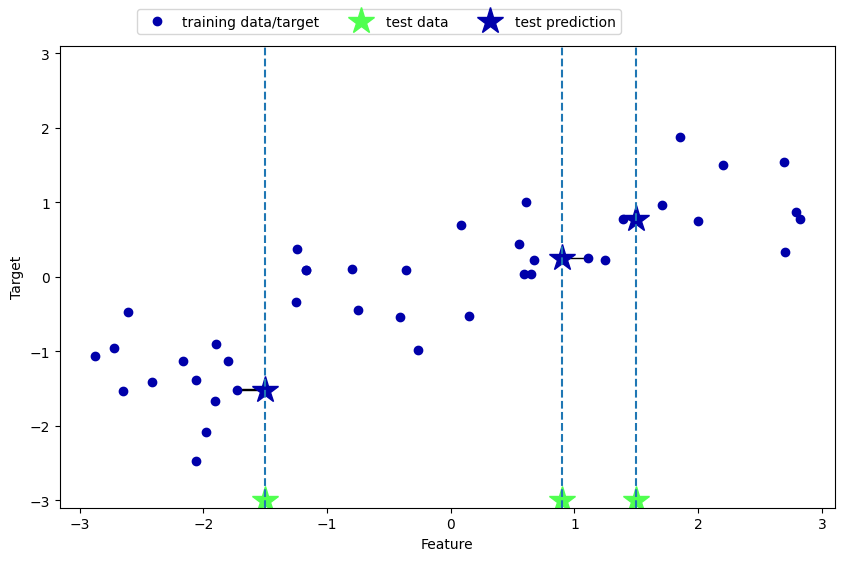

In [22]:
mglearn.plots.plot_knn_regression(n_neighbors=1)

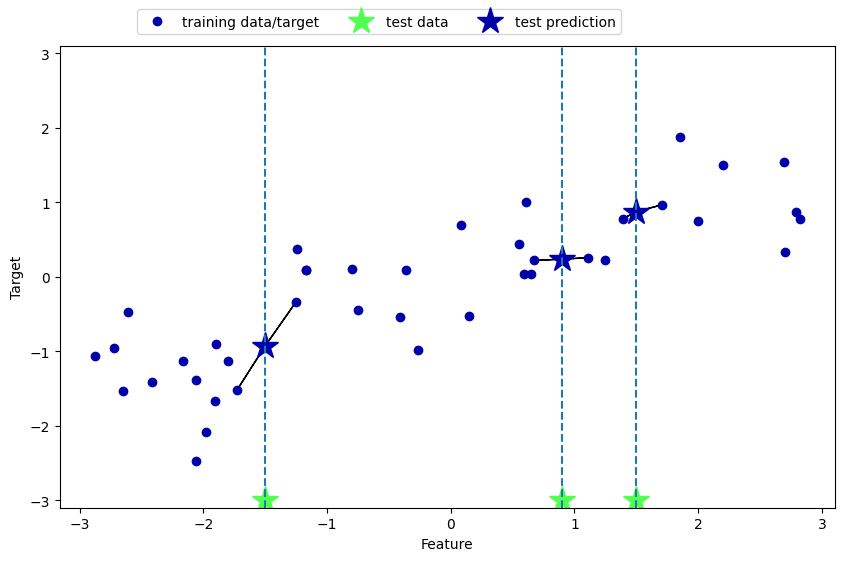

In [23]:
mglearn.plots.plot_knn_regression(n_neighbors=2)

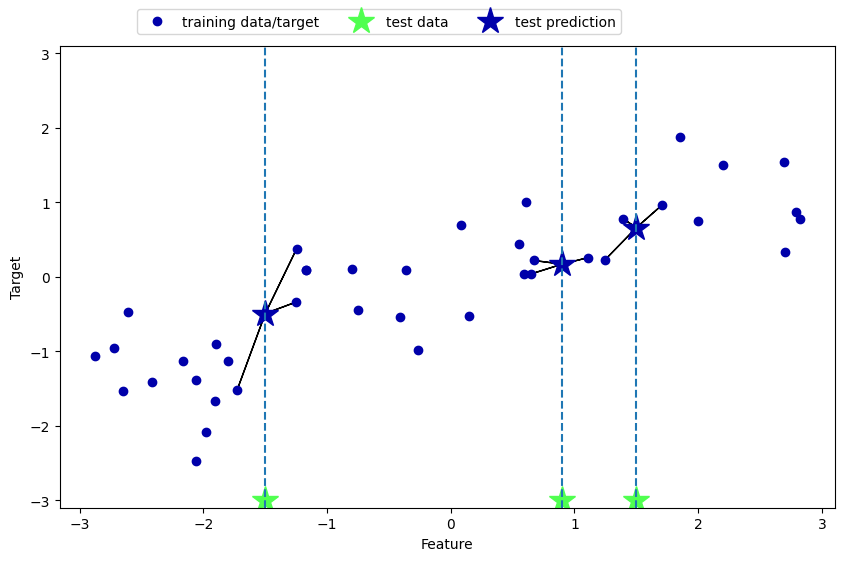

In [24]:
mglearn.plots.plot_knn_regression(n_neighbors=3)

In [25]:
from sklearn.neighbors import KNeighborsRegressor
X,y = mglearn.datasets.make_wave(n_samples=40)
# split the wave dataset into training and test one
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=0)
#Instantiate the model and set the number of neighbors to consider to 3
reg = KNeighborsRegressor(n_neighbors=3)
#Fit the model using the training data and training targets
reg.fit(X_train,y_train)

KNeighborsRegressor(n_neighbors=3)

In [26]:
print("Test set Prediction :\n{}".format(reg.predict(X_test)))

Test set Prediction :
[-0.05396539  0.35686046  1.13671923 -1.89415682 -1.13881398 -1.63113382
  0.35686046  0.91241374 -0.44680446 -1.13881398]


In [27]:
print ("Test set R^2 :{:.2f}".format(reg.score(X_test,y_test)))

Test set R^2 :0.83


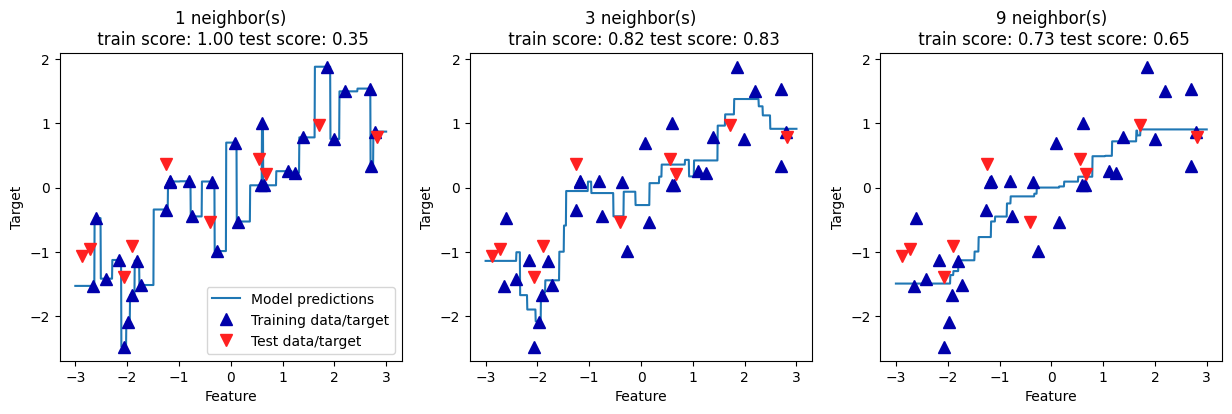

In [28]:
fig,axes=plt.subplots(1,3,figsize=(15,4))
#create 1,000 data points, evenly spaced between -3 and 3
line=np.linspace(-3,3,1000).reshape(-1,1)
for n_neighbors,ax in zip([1,3,9],axes):
   #make predictions using 1,3,or 9 neighbors
   reg=KNeighborsRegressor(n_neighbors=n_neighbors)
   reg.fit(X_train,y_train)
   ax.plot(line,reg.predict(line))
   ax.plot(X_train,y_train,'^',c=mglearn.cm2(0),markersize=8)
   ax.plot(X_test,y_test,'v',c=mglearn.cm2(1),markersize=8)
   ax.set_title(
        "{} neighbor(s)\n train score: {:.2f} test score: {:.2f}".format(
            n_neighbors, reg.score(X_train, y_train),
            reg.score(X_test, y_test)))
   ax.set_xlabel("Feature")
   ax.set_ylabel("Target")
axes[0].legend(["Model predictions", "Training data/target",
 "Test data/target"], loc="best")